In [1]:
# 1 Given a CSV file containing Zomato restaurant ratings, use pandas to detect outliers in the 'user_rating' column using the IQR method and print the indices of the detected outliers.

import pandas as pd

# Load the CSV file
import pandas as pd

df = pd.read_csv("zomato.csv", encoding="latin1")
df.head()



,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


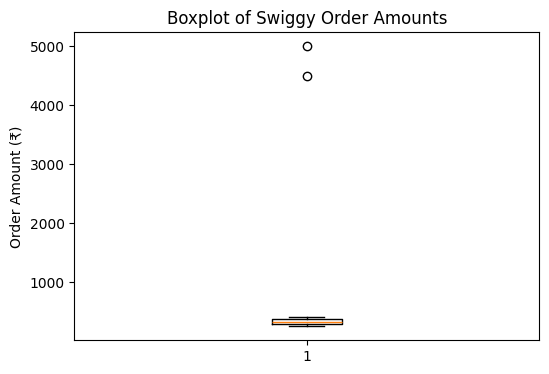

In [2]:
# 2 
import pandas as pd
import matplotlib.pyplot as plt

# Dummy Swiggy orders dataset
data = {
    'order_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110,
                 111, 112, 113, 114, 115],
    'order_amount': [250, 320, 280, 400, 350, 290, 310, 270, 330,
                     360, 300, 275, 5000, 4500, 380]
}

df = pd.DataFrame(data)

# Create boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(df['order_amount'])

# Labels and title
plt.ylabel('Order Amount (₹)')
plt.title('Boxplot of Swiggy Order Amounts')

plt.show()

In [3]:
# 3 
import pandas as pd
import numpy as np

# Dummy Paytm transactions dataset
df = pd.DataFrame({
    'transaction_id': range(1, 21),
    'transaction_amount': [
        50, 100, 120, 150, 180, 200, 220, 250, 280, 300,
        320, 350, 400, 450, 500, 550, 600, 700, 5000, 10000
    ]
})

print("Original Statistics:")
print(df['transaction_amount'].describe())

# Calculate 5th and 95th percentiles
lower_limit = df['transaction_amount'].quantile(0.05)
upper_limit = df['transaction_amount'].quantile(0.95)

# Apply Winsorization
df['transaction_amount'] = np.clip(
    df['transaction_amount'],
    lower_limit,
    upper_limit
)

print("\nUpdated Statistics After Winsorization:")
print(df['transaction_amount'].describe())

print("\nWinsorized Transaction Amounts:")
print(df['transaction_amount'])

Original Statistics:
count       20.000000
mean      1036.000000
std       2361.144682
min         50.000000
25%        195.000000
50%        310.000000
75%        512.500000
max      10000.000000
Name: transaction_amount, dtype: float64

Updated Statistics After Winsorization:
count      20.000000
mean      800.875000
std      1489.127101
min        97.500000
25%       195.000000
50%       310.000000
75%       512.500000
max      5250.000000
Name: transaction_amount, dtype: float64

Winsorized Transaction Amounts:
0       97.5
1      100.0
2      120.0
3      150.0
4      180.0
5      200.0
6      220.0
7      250.0
8      280.0
9      300.0
10     320.0
11     350.0
12     400.0
13     450.0
14     500.0
15     550.0
16     600.0
17     700.0
18    5000.0
19    5250.0
Name: transaction_amount, dtype: float64


In [4]:
# 4 
import pandas as pd

# Dummy Flipkart product dataset
df = pd.DataFrame({
    'product_name': ['Mobile', 'Laptop', 'Headphones', 'Smartwatch'],
    'price': ['₹12,999', '₹59,999', '₹2,499', '₹4,999']
})

print("Original DataFrame:")
print(df)

# Remove non-numeric characters and convert to numeric
df['price'] = (
    df['price']
    .str.replace('₹', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

print("\nUpdated DataFrame:")
print(df)

print("\nData Types:")
print(df.dtypes)

Original DataFrame:
  product_name    price
0       Mobile  ₹12,999
1       Laptop  ₹59,999
2   Headphones   ₹2,499
3   Smartwatch   ₹4,999

Updated DataFrame:
  product_name    price
0       Mobile  12999.0
1       Laptop  59999.0
2   Headphones   2499.0
3   Smartwatch   4999.0

Data Types:
product_name     object
price           float64
dtype: object


In [5]:
# 5 
import pandas as pd

# Dummy Spotify user DataFrame
df = pd.DataFrame({
    'user_id': [101, 102, 103, 104, 105, 106],
    'is_premium': [True, 'True', 1, 'yes', 'False', 0]
})

print("Original DataFrame:")
print(df)

# Convert mixed values to boolean
true_values = {'true', '1', 'yes'}

df['is_premium'] = df['is_premium'].apply(
    lambda x: str(x).strip().lower() in true_values
)

print("\nUpdated DataFrame:")
print(df)

print("\nData Types:")
print(df.dtypes)

Original DataFrame:
   user_id is_premium
0      101       True
1      102       True
2      103          1
3      104        yes
4      105      False
5      106          0

Updated DataFrame:
   user_id  is_premium
0      101        True
1      102        True
2      103        True
3      104        True
4      105       False
5      106       False

Data Types:
user_id       int64
is_premium     bool
dtype: object
